# L26 · 🎨 微积分可视化 — 切线（tangent line）、等高线（contour line）与梯度（gradient）下降（gradient descent，GD）轨迹动态演示

配合 `c1–c4`，用 `cviz` 把切线斜率（tangent slope）、梯度箭头和下降步骤画出来。Aurora 训练时打印的 `loss` 曲线，正是 `contour_descent` 里那条折线在损失轴上的投影。

**目标**：用 `cviz` 把切线斜率动画、梯度箭头和梯度下降（gradient descent）轨迹画出来，把"导数 = 斜率""梯度 = 最陡上升方向"从公式转为可见的几何对象。

**为什么对 Aurora 重要**：Aurora 训练时打印的 `loss` 曲线对应 `contour_descent` 里那条折线在损失轴的投影；梯度箭头的方向就是 `optimizer.step()` 每次走的方向。

## 本课剧情：把坡度画出来

切线斜率说明函数在某点的变化方向，梯度把这个方向推广到多维，梯度下降则沿梯度反方向一步步走向最低点。这节课用 `tangent`、`descent_1d`、`contour_descent` 把三件事各画一张图，再用 `lr_compare` 对比三种学习率（learning rate，lr）的收敛行为。

In [1]:
import numpy as np
from cviz import style, tangent, descent_1d, contour_descent, lr_compare
style(); print('cviz 就绪')

cviz 就绪


## 实验入口：用数值变化观察函数

用中心差分（central difference，CD） `(f(x+h)−f(x−h))/(2h)` 在五个点上算 `f(x) = x²` 的近似斜率，和理论值 `2x` 逐行对照。

## 动手观察：变化率不是一句口号

对 `f(x) = x²` 取 `h = 1e-3`，中心差分的结果和理论值 `2x` 精确到小数点后三位。

In [ ]:
import numpy as np

def f(x):
    return x**2

xs = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
h = 1e-3
slopes = (f(xs + h) - f(xs - h)) / (2 * h)

print('x =', xs)
print('f(x) =', f(xs))
print('近似斜率 =', np.round(slopes, 3))
print('理论斜率 2x =', 2 * xs)


## 代码实验：遍历不同位置，看斜率如何变化

对 `f(x) = x² + 2x` 从 `x = −3` 到 `x = 3` 逐点打印函数值和斜率，观察斜率在 `x = −1` 附近过零。

In [ ]:
import numpy as np

def f(x):
    return x**2 + 2*x

h = 1e-4
for x in np.linspace(-3, 3, 7):
    slope = (f(x + h) - f(x - h)) / (2*h)
    print(f'x={x:5.2f} | f(x)={f(x):6.2f} | slope≈{slope:6.2f}')


## 1. 导数（derivative） = 切线斜率（对应 c1）

`tangent(f, grad_f, x0)` 在点 `x0` 画出函数曲线与切线，切线斜率即 `f'(x0)`。对 `f(x) = x^2`，`x0 = 1.5` 处切线斜率为 `3.0`，负数区域斜率为负，顶点 `x0 = 0` 处斜率恰好为零，极小值 = 梯度归零的地方。

这个画面是整节课的几何基础。梯度下降的视觉化有两个关键画面：一维时是沿曲线下滑，每一步按导数反方向移动；二维时是垂直等高线向低处移动，步进方向始终与等高线正交。学习率的影响在图上立刻可见：lr 过大时轨迹在谷底左右弹跳，lr 适中时螺旋收敛到极小值。先把一维的斜率等于下山方向看清楚，多维情况下的梯度等于最陡上升方向取反就顺理成章了。

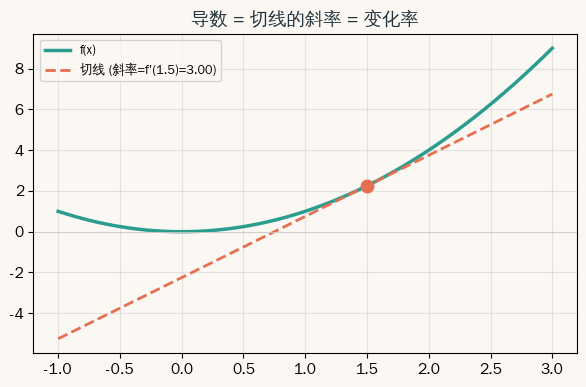

In [2]:
tangent(lambda x: x**2, lambda x: 2*x, x0=1.5);

## 2. 一维梯度下降：沿斜坡滚到最低点（对应 c4）

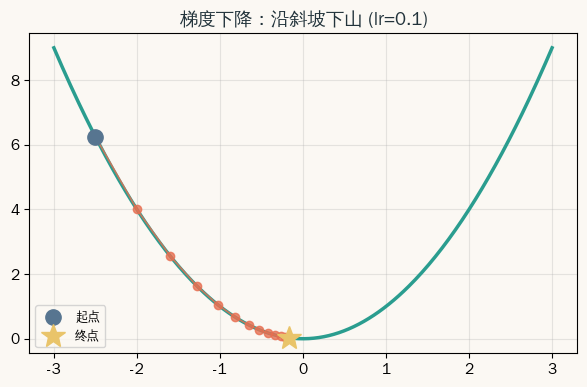

In [3]:
descent_1d(lambda x:(x)**2, lambda x:2*x, x0=-2.5, lr=0.1);

## 3. 二维梯度下降：垂直等高线下山（对应 c2 梯度 + c4）

**Aurora**：`contour_descent(start, lr, steps)` 画出的折线就是神经网络参数更新路径的缩影。Aurora 实际训练时，`src/aurora/audio/` 下的损失函数由反向传播自动提供梯度，但每步更新规则与这里完全一致：只是参数空间从二维扩展到几百万维，折线变成了超高维空间里的一条轨迹。

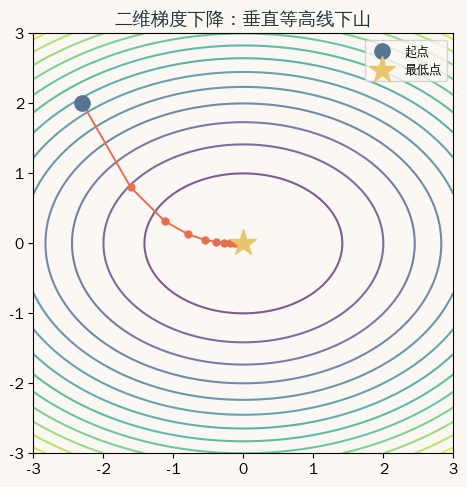

In [4]:
contour_descent(start=(-2.3, 2.0), lr=0.15);

## 4. 学习率的影响：太小慢 / 适中 / 太大震荡

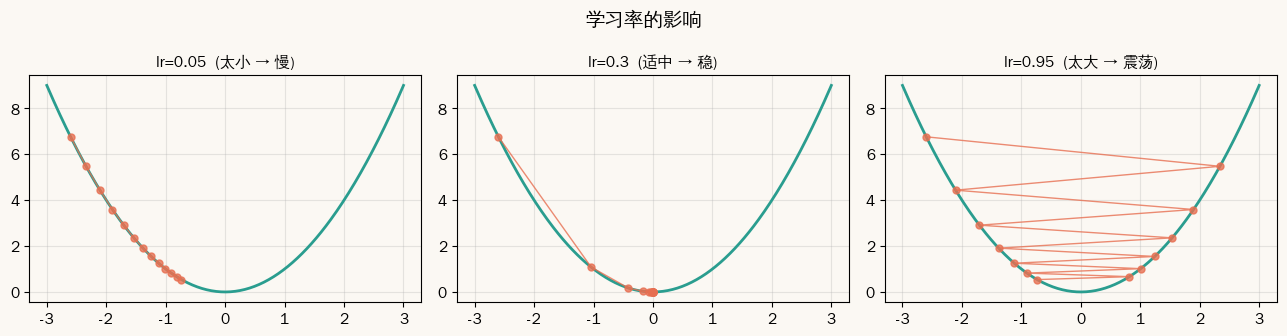

In [5]:
lr_compare();

In [ ]:
# 参数实验 1：从极小值点旁出发，lr=0.5 观察振荡
contour_descent(start=(0.1, 0.1), lr=0.5)
# 预期：f(x,y)=x²+2y² 是凸函数，(0,0) 是全局极小值；lr 较大时轨迹在极值点附近左右弹跳


## 参数实验：从极小值（minimum）旁边出发

在 `contour_descent` 里把 `start` 改为 `(0.1, 0.1)`，让轨迹从极小值点旁边出发。注意：`f(x,y)=x²+2y²` 是**凸函数**，(0,0) 处是全局极小值而非鞍点（saddle point）。真正的鞍点需要函数在某方向上升、另一方向下降，例如 `f(x,y)=x²−y²`。梯度下降对凸函数必然收敛；深度学习中的非凸损失才会出现鞍点。

对比实验：保持 `start=(0.1, 0.1)`，把 `lr` 从 `0.15` 改成 `0.5`，观察轨迹是否在极值点附近左右弹跳；再把 `lr` 降回 `0.05`，看收敛步数如何随之增加。

In [ ]:
# 对比实验：同一起点，lr=0.05 观察慢收敛
contour_descent(start=(0.1, 0.1), lr=0.05)
# 预期：每步步幅小，路径稳定趋向极值点，步数明显多于 lr=0.5


## 本课收束

现在能用 `tangent` 在任意点画切线，用 `descent_1d` 和 `contour_descent` 把梯度下降的每一步轨迹可视化，用 `lr_compare` 并排看三种学习率的收敛差异。这条折线轨迹就是 Aurora 模型训练时 `loss` 曲线的几何来源：每个 epoch 的 loss 值对应参数空间里的一个位置，打印出来的是它在损失轴上的投影。`c4` 把同样的更新规则 `x ← x − lr·∇f(x)` 用在实际音频损失函数上，形式完全一样。

下一课（L27）转入概率基础：事件（event）、条件概率（conditional probability）和大数定律（LLN），这是理解交叉熵损失的统计前提。